In [ ]:
import os
import pandas as pd
import numpy as np

# A base completa original (train_ver2.csv) possui 2.2 GB.
# Para viabilizar a execução sem estouro de memória e permitir o versionamento no Git,
# disponibilizamos a subamostra oficial de 30.000 clientes compactada (gzip).

caminho_amostra_gz = 'santander_30k_sample.csv.gz'

if os.path.exists(caminho_amostra_gz):
    print("Carregando amostra otimizada de 30.000 clientes...")
    df = pd.read_csv(caminho_amostra_gz, compression='gzip', low_memory=False)
    print(f"Sucesso! Registros carregados: {df.shape[0]:,} | Clientes: {df['ncodpers'].nunique():,}")
else:
    # Fluxo alternativo: Caso queira reprocessar o arquivo bruto do Kaggle
    caminho_bruto = 'train_ver2.csv'

    if not os.path.exists(caminho_bruto):
        raise FileNotFoundError(
            f"Arquivo '{caminho_amostra_gz}' não encontrado. "
            "Certifique-se de clonar o repositório completo ou disponibilizar 'train_ver2.csv'."
        )

    print("Mapeando IDs únicos a partir do arquivo bruto...")
    df_ids = pd.read_csv(caminho_bruto, usecols=['ncodpers'], dtype={'ncodpers': np.int32})
    clientes_unicos = df_ids['ncodpers'].unique()
    del df_ids

    np.random.seed(42)
    clientes_amostra = set(np.random.choice(clientes_unicos, size=30000, replace=False))

    print("Extraindo fatias temporais dos 30.000 clientes selecionados...")
    chunks_filtrados = [
        chunk[chunk['ncodpers'].isin(clientes_amostra)]
        for chunk in pd.read_csv(caminho_bruto, chunksize=1_000_000, low_memory=False)
    ]
    df = pd.concat(chunks_filtrados, ignore_index=True)
    del chunks_filtrados

    df.to_csv(caminho_amostra_gz, index=False, compression='gzip')
    print("Amostra extraída e compactada com sucesso!")

Carregando amostra otimizada de 30.000 clientes...
Sucesso! Registros carregados: 427,751 | Clientes: 30,000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Conversão de tipos numéricos e tratamento de nulos
cols_numeric = ['age', 'antiguedad', 'renta']
for col in cols_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

target_cols = [c for c in df.columns if c.startswith('ind_') and c.endswith('_ult1')]
df[target_cols] = df[target_cols].fillna(0).astype(int)

print(f"Dataset limpo: {df.shape[0]:,} linhas e {df.shape[1]} colunas.")

print("\n--- RESUMO ESTATÍSTICO ---")
display(df[cols_numeric].describe())

produtos_binarios = all(set(df[col].unique()).issubset({0, 1}) for col in target_cols)
print(f"\nConsistência binária dos produtos: {'OK' if produtos_binarios else 'FALHA'}")

print("\n--- DISTRIBUIÇÃO TEMPORAL ---")
print(df['fecha_dato'].value_counts().sort_index())

Dataset limpo: 427,751 linhas e 48 colunas.

--- RESUMO ESTATÍSTICO ---


,age,antiguedad,renta
count,426826.00000,426826.000000,3.402460e+05
mean,40.03966,78.769513,1.336902e+05
std,17.19521,66.286352,2.275786e+05
min,2.00000,0.000000,6.750000e+03
25%,24.00000,23.000000,6.921360e+04
50%,38.00000,49.000000,1.020594e+05
75%,50.00000,133.000000,1.565414e+05
max,112.00000,256.000000,2.889440e+07



Consistência binária dos produtos: OK

--- DISTRIBUIÇÃO TEMPORAL ---
fecha_dato
2015-01-28    19595
2015-02-28    19665
2015-03-28    19740
2015-04-28    19809
2015-05-28    19847
2015-06-28    19863
2015-07-28    26061
2015-08-28    26436
2015-09-28    27151
2015-10-28    27957
2015-11-28    28412
2015-12-28    28578
2016-01-28    28676
2016-02-28    28824
2016-03-28    28942
2016-04-28    29053
2016-05-28    29142
Name: count, dtype: int64


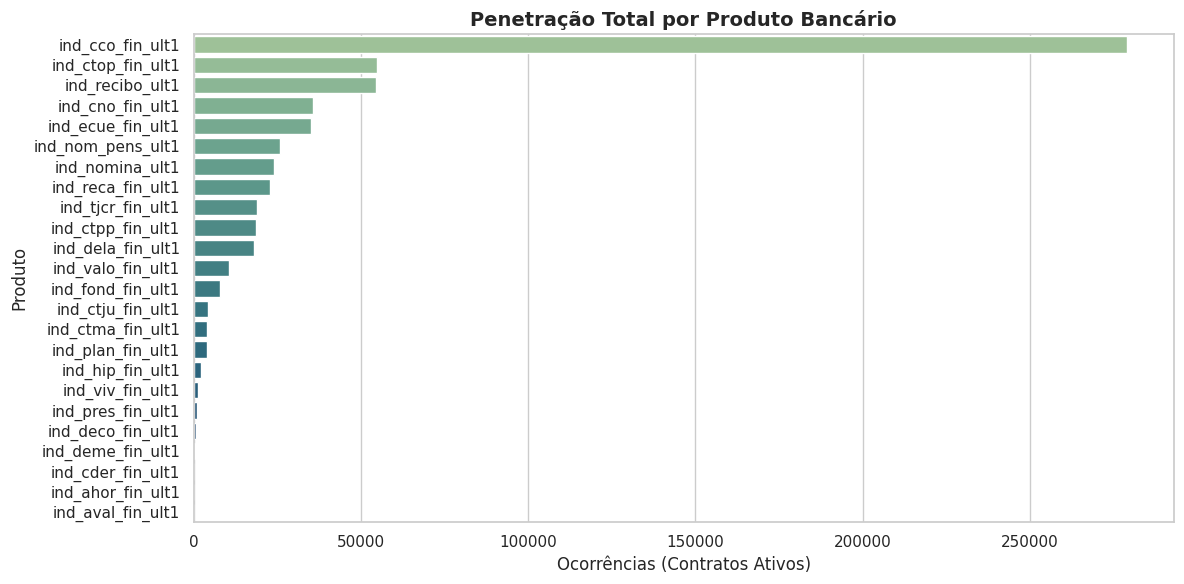

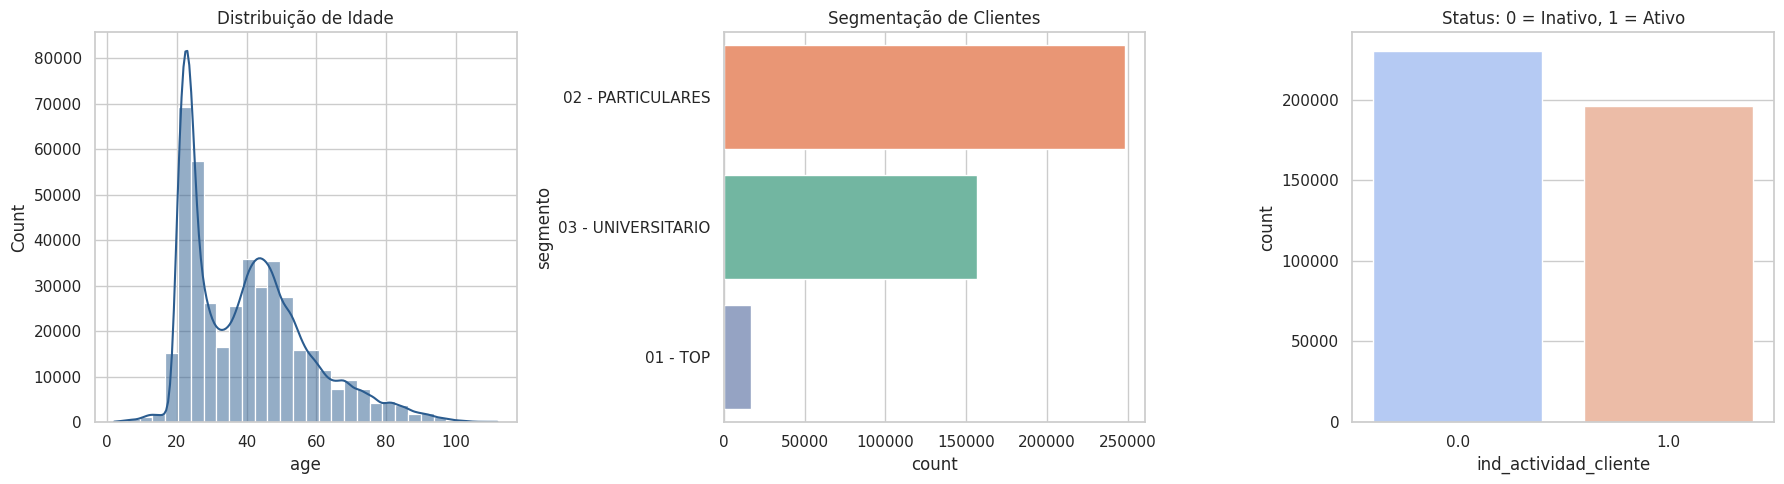

In [ ]:
produtos_total = df[target_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=produtos_total.values,
    y=produtos_total.index,
    hue=produtos_total.index,
    palette='crest',
    legend=False
)
plt.title('Penetração Total por Produto Bancário', fontsize=14, fontweight='bold')
plt.xlabel('Ocorrências (Contratos Ativos)')
plt.ylabel('Produto')
plt.tight_layout()
plt.savefig('grafico_produtos_populares.png', dpi=300)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['age'].dropna(), bins=30, kde=True, ax=axes[0], color='#2b5c8f')
axes[0].set_title('Distribuição de Idade')

sns.countplot(
    y='segmento',
    data=df,
    ax=axes[1],
    hue='segmento',
    palette='Set2',
    order=df['segmento'].value_counts().index,
    legend=False
)
axes[1].set_title('Segmentação de Clientes')

sns.countplot(
    x='ind_actividad_cliente',
    data=df,
    ax=axes[2],
    hue='ind_actividad_cliente',
    palette='coolwarm',
    legend=False
)
axes[2].set_title('Status: 0 = Inativo, 1 = Ativo')

plt.tight_layout()
plt.savefig('grafico_demografico.png', dpi=300)
plt.show()

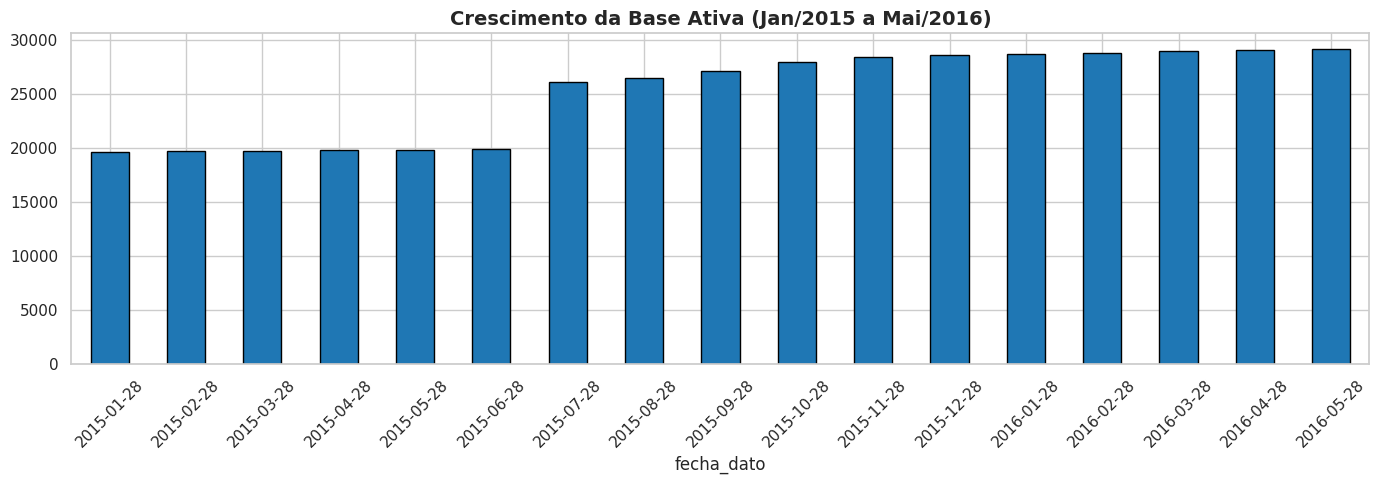

Top 10 produtos mais adquiridos no período:


,0
ind_recibo_ult1,4874
ind_nom_pens_ult1,2735
ind_nomina_ult1,2390
ind_cco_fin_ult1,2194
ind_tjcr_fin_ult1,2177
ind_cno_fin_ult1,1185
ind_ecue_fin_ult1,837
ind_dela_fin_ult1,375
ind_reca_fin_ult1,289
ind_ctma_fin_ult1,225


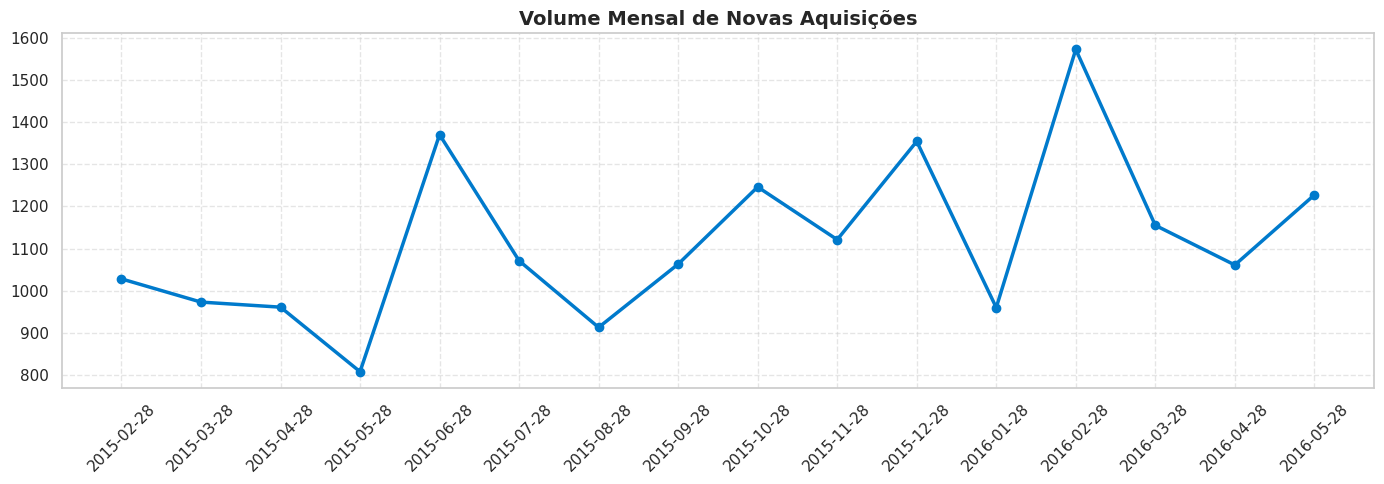

Treino (até 2016-02-28): 340,614 registros
Validação (2016-03-28 a 2016-05-28): 87,137 registros


In [ ]:
plt.figure(figsize=(14, 5))
df['fecha_dato'].value_counts().sort_index().plot(kind='bar', color='#1f77b4', edgecolor='black')
plt.title('Crescimento da Base Ativa (Jan/2015 a Mai/2016)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Cálculo de novas adesões (0 -> 1)
df_sorted = df.sort_values(['ncodpers', 'fecha_dato'])
novas_adesoes = (df_sorted.groupby('ncodpers')[target_cols].diff() == 1).astype(int)
novas_adesoes['fecha_dato'] = df_sorted['fecha_dato']

print("Top 10 produtos mais adquiridos no período:")
display(novas_adesoes[target_cols].sum().sort_values(ascending=False).head(10))

adesao_por_mes = novas_adesoes.groupby('fecha_dato').sum().iloc[1:]

plt.figure(figsize=(14, 5))
plt.plot(adesao_por_mes.index, adesao_por_mes.sum(axis=1), marker='o', color='#007acc', linewidth=2.5)
plt.title('Volume Mensal de Novas Aquisições', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Split Cronológico
corte_treino = '2016-02-28'
inicio_validacao = '2016-03-28'
fim_validacao = '2016-05-28'

df_train_split = df[df['fecha_dato'] <= corte_treino].copy()
df_val_split = df[(df['fecha_dato'] >= inicio_validacao) & (df['fecha_dato'] <= fim_validacao)].copy()

print(f"Treino (até {corte_treino}): {df_train_split.shape[0]:,} registros")
print(f"Validação ({inicio_validacao} a {fim_validacao}): {df_val_split.shape[0]:,} registros")